# 🚗 DoorDash Delivery Prediction
## Notebook 04 — Advanced Modeling & Comparison

**Goal:** Train, compare, and deeply understand 12 regression models.

**Target:** `total_delivery_duration_mins`

**Metrics:**
- **MAE** — Mean Absolute Error: avg minutes off (most interpretable)
- **RMSE** — Root Mean Squared Error: penalises large errors more
- **R²** — How much variance is explained (1.0 = perfect, 0 = no better than guessing the mean)
- **CV Score** — Cross-validated MAE: how the model performs across different data splits

**Model families covered:**
1. Linear Models (Ridge, Lasso, ElasticNet)
2. Instance-Based (KNN)
3. Tree Models (Decision Tree, Random Forest)
4. Gradient Boosting (GBM, XGBoost, LightGBM, CatBoost)
5. Support Vector (SVR)
6. Meta-Learners (Voting Ensemble, Stacking)

**Author:** Divyargarg

---

In [2]:
# ── CELL 1: Import All Libraries ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Linear Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Instance-Based
from sklearn.neighbors import KNeighborsRegressor

# Support Vector
from sklearn.svm import SVR

# Tree Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor
)

# Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print('✅ All libraries loaded!')

✅ All libraries loaded!


In [3]:
# ── CELL 2: Load Data ─────────────────────────────────────────────────
df = pd.read_csv('../data/features/features_data.csv')

TARGET = 'total_delivery_duration_mins'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Encode categoricals
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    if X[col].nunique() <= 10:
        dummies = pd.get_dummies(X[col], prefix=col, drop_first=True)
        X = pd.concat([X.drop(columns=[col]), dummies], axis=1)
    else:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

print(f'✅ Data loaded | Shape: {df.shape}')
print(f'📊 Features: {X.shape[1]} | Target mean: {y.mean():.1f} mins')

✅ Data loaded | Shape: (197283, 16)
📊 Features: 15 | Target mean: 47.5 mins


In [4]:
# ── CELL 3: Train / Val / Test Split & Scaling ────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Scale — fit on train ONLY
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')

Train: 138098 | Val: 29592 | Test: 29593


In [5]:
# ── CELL 4: Universal Evaluation Helper ───────────────────────────────
all_results = []   # We'll collect every model's results here

def evaluate(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te, cv_X=None, cv_y=None):
    """
    Trains model, evaluates on val + test sets, runs cross-validation.
    Stores results globally for final comparison.
    """
    model.fit(X_tr, y_tr)

    # Validation metrics
    val_pred  = model.predict(X_v)
    val_mae   = mean_absolute_error(y_v, val_pred)
    val_rmse  = np.sqrt(mean_squared_error(y_v, val_pred))
    val_r2    = r2_score(y_v, val_pred)

    # Test metrics
    test_pred = model.predict(X_te)
    test_mae  = mean_absolute_error(y_te, test_pred)
    test_r2   = r2_score(y_te, test_pred)

    # Cross-validation (5-fold)
    cv_mae = None
    if cv_X is not None:
        cv_scores = cross_val_score(model, cv_X, cv_y,
                                    cv=KFold(n_splits=5, shuffle=True, random_state=42),
                                    scoring='neg_mean_absolute_error')
        cv_mae = -cv_scores.mean()

    result = {
        'Model'       : name,
        'Val MAE'     : round(val_mae, 3),
        'Val RMSE'    : round(val_rmse, 3),
        'Val R²'      : round(val_r2, 4),
        'Test MAE'    : round(test_mae, 3),
        'Test R²'     : round(test_r2, 4),
        'CV MAE'      : round(cv_mae, 3) if cv_mae else 'N/A',
    }
    all_results.append(result)

    print(f'  Val  → MAE: {val_mae:.3f} | RMSE: {val_rmse:.3f} | R²: {val_r2:.4f}')
    print(f'  Test → MAE: {test_mae:.3f} | R²: {test_r2:.4f}')
    if cv_mae:
        print(f'  CV   → MAE: {cv_mae:.3f} (5-fold)')
    return model

print('✅ evaluate() helper ready — collecting all results automatically')

✅ evaluate() helper ready — collecting all results automatically


---
## 📐 Family 1 — Linear Models

**Core idea:** Fit a straight line (or hyperplane) through the data.
Best when the relationship between features and target is approximately linear.

**Regularization** adds a penalty for large coefficients to prevent overfitting:
- **Ridge (L2):** Shrinks all coefficients — never fully zeros them out
- **Lasso (L1):** Can zero out coefficients — acts as automatic feature selection
- **ElasticNet:** Mix of both — balances between the two penalties

**Key parameter to tune:** `alpha` — controls how strong the penalty is
- Low alpha → closer to plain linear regression (risk of overfitting)
- High alpha → heavier penalty (risk of underfitting)

In [6]:
# ── CELL 5: Ridge Regression ──────────────────────────────────────────
# L2 regularization — shrinks all coefficients but never to zero
# alpha=1.0 is the default — try 0.1, 1, 10, 100 to see the effect

print('🔵 Ridge Regression (alpha=1.0):')
ridge = evaluate('Ridge (α=1)', Ridge(alpha=1.0),
                  X_train_s, y_train, X_val_s, y_val, X_test_s, y_test,
                  X_train_s, y_train)

# --- EXPERIMENT: How does alpha change results? ---
print('\n📊 Ridge Alpha Sensitivity:')
print(f'{"Alpha":<12} {"Val MAE":<12} {"Val R²"}')
print('-' * 36)
for alpha in [0.01, 0.1, 1, 10, 100, 1000]:
    m = Ridge(alpha=alpha).fit(X_train_s, y_train)
    pred = m.predict(X_val_s)
    mae = mean_absolute_error(y_val, pred)
    r2  = r2_score(y_val, pred)
    print(f'{alpha:<12} {mae:<12.3f} {r2:.4f}')
print('💡 Watch how R² degrades at very high alpha — the model becomes too simple')

🔵 Ridge Regression (alpha=1.0):
  Val  → MAE: 12.468 | RMSE: 16.739 | R²: 0.1413
  Test → MAE: 12.414 | R²: 0.1349
  CV   → MAE: 12.446 (5-fold)

📊 Ridge Alpha Sensitivity:
Alpha        Val MAE      Val R²
------------------------------------
0.01         12.468       0.1413
0.1          12.468       0.1413
1            12.468       0.1413
10           12.468       0.1413
100          12.468       0.1413
1000         12.468       0.1413
💡 Watch how R² degrades at very high alpha — the model becomes too simple


In [7]:
# ── CELL 6: Lasso Regression ──────────────────────────────────────────
# L1 regularization — can zero out coefficients entirely
# This makes Lasso act as a built-in feature selector

print('🔵 Lasso Regression (alpha=0.1):')
lasso = evaluate('Lasso (α=0.1)', Lasso(alpha=0.1, max_iter=5000),
                  X_train_s, y_train, X_val_s, y_val, X_test_s, y_test,
                  X_train_s, y_train)

# How many features did Lasso zero out?
lasso_coefs = pd.Series(lasso.coef_, index=X.columns)
zeroed = (lasso_coefs == 0).sum()
kept   = (lasso_coefs != 0).sum()
print(f'\n💡 Lasso zeroed out {zeroed} features and kept {kept}')
print('Top 10 features Lasso values most:')
print(lasso_coefs.abs().sort_values(ascending=False).head(10))

🔵 Lasso Regression (alpha=0.1):
  Val  → MAE: 12.474 | RMSE: 16.748 | R²: 0.1404
  Test → MAE: 12.422 | R²: 0.1343
  CV   → MAE: 12.452 (5-fold)

💡 Lasso zeroed out 3 features and kept 12
Top 10 features Lasso values most:
estimated_store_to_consumer_driving_duration    4.042459
subtotal                                        2.499243
is_weekend                                      2.335031
order_hour                                      2.221449
order_day_of_week                               1.817185
estimated_order_place_duration                  1.674602
order_month                                     0.844997
total_items                                     0.480652
max_item_price                                  0.385776
is_rush_hour                                    0.316540
dtype: float64


In [8]:
# ── CELL 7: ElasticNet ────────────────────────────────────────────────
# Combines Ridge (L2) + Lasso (L1)
# l1_ratio=0 → pure Ridge | l1_ratio=1 → pure Lasso | 0.5 → equal mix
# Good when you have correlated features AND want some feature selection

print('🔵 ElasticNet (alpha=0.1, l1_ratio=0.5):')
enet = evaluate('ElasticNet', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
                 X_train_s, y_train, X_val_s, y_val, X_test_s, y_test,
                 X_train_s, y_train)

print('\n📊 ElasticNet l1_ratio Sensitivity (how much Lasso vs Ridge):')
print(f'{"l1_ratio":<12} {"Val MAE":<12} {"Val R²"}')
print('-' * 36)
for ratio in [0.0, 0.2, 0.5, 0.8, 1.0]:
    m = ElasticNet(alpha=0.1, l1_ratio=ratio, max_iter=5000).fit(X_train_s, y_train)
    pred = m.predict(X_val_s)
    print(f'{ratio:<12} {mean_absolute_error(y_val, pred):<12.3f} {r2_score(y_val, pred):.4f}')
print('💡 l1_ratio=0 → Ridge | l1_ratio=1 → Lasso')

🔵 ElasticNet (alpha=0.1, l1_ratio=0.5):
  Val  → MAE: 12.477 | RMSE: 16.754 | R²: 0.1398
  Test → MAE: 12.424 | R²: 0.1341
  CV   → MAE: 12.455 (5-fold)

📊 ElasticNet l1_ratio Sensitivity (how much Lasso vs Ridge):
l1_ratio     Val MAE      Val R²
------------------------------------
0.0          12.481       0.1391
0.2          12.479       0.1394
0.5          12.477       0.1398
0.8          12.475       0.1402
1.0          12.474       0.1404
💡 l1_ratio=0 → Ridge | l1_ratio=1 → Lasso


---
## 📍 Family 2 — Instance-Based: K-Nearest Neighbors

**Core idea:** No training phase. To predict a new order's duration, find the K most similar historical orders and average their delivery times.

**Key parameter:** `n_neighbors` (K)
- Low K (1-3) → very sensitive to noise, overfits
- High K (50+) → too smooth, underfits
- Sweet spot is usually between 5-20

**Weakness:** Slow on large datasets. Needs scaling — distance is meaningless without it.

🟣 KNN Regressor (k=10):
  Val  → MAE: 12.534 | RMSE: 16.956 | R²: 0.1189
  Test → MAE: 12.489 | R²: 0.1126

📊 KNN — Effect of K on performance:
K        Val MAE      Val R²
--------------------------------
1        16.583       -0.5746
3        13.762       -0.0545
5        13.081       0.0504
10       12.534       0.1189
20       12.298       0.1503
50       12.185       0.1648
100      12.163       0.1659


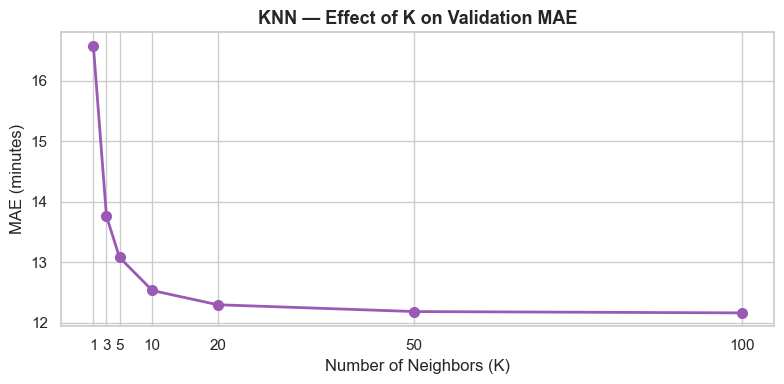

💡 Low K = overfit (wiggly) | High K = underfit (too smooth)


In [9]:
# ── CELL 8: KNN Regressor ─────────────────────────────────────────────
print('🟣 KNN Regressor (k=10):')
knn = evaluate('KNN (k=10)', KNeighborsRegressor(n_neighbors=10),
                X_train_s, y_train, X_val_s, y_val, X_test_s, y_test)

# K sensitivity — the bias-variance tradeoff in action
print('\n📊 KNN — Effect of K on performance:')
print(f'{"K":<8} {"Val MAE":<12} {"Val R²"}')
print('-' * 32)
k_maes = []
k_vals = [1, 3, 5, 10, 20, 50, 100]
for k in k_vals:
    m = KNeighborsRegressor(n_neighbors=k).fit(X_train_s, y_train)
    pred = m.predict(X_val_s)
    mae = mean_absolute_error(y_val, pred)
    k_maes.append(mae)
    print(f'{k:<8} {mae:<12.3f} {r2_score(y_val, pred):.4f}')

# Plot K vs MAE
plt.figure(figsize=(8, 4))
plt.plot(k_vals, k_maes, 'o-', color='#9B59B6', linewidth=2, markersize=7)
plt.title('KNN — Effect of K on Validation MAE', fontsize=13, fontweight='bold')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('MAE (minutes)')
plt.xticks(k_vals)
plt.tight_layout()
plt.savefig('../outputs/figures/04_knn_k_sensitivity.png', dpi=150)
plt.show()
print('💡 Low K = overfit (wiggly) | High K = underfit (too smooth)')

---
## 🌳 Family 3 — Tree Models

**Core idea:** Split data into branches using yes/no rules on features.
> e.g. "Is order_hour > 18? → Yes → Is estimated_duration > 1800? → ..."

**Decision Tree:** Single tree — fast, explainable, but overfits easily.

**Random Forest:** Builds hundreds of trees on random subsets of data and features, then averages predictions. The randomness reduces overfitting.

**Key parameters:**
- `max_depth` — how deep each tree grows (deeper = more complex = risk of overfit)
- `n_estimators` — how many trees in the forest (more = better, but slower)

In [10]:
# ── CELL 9: Decision Tree ─────────────────────────────────────────────
print('🌳 Decision Tree (max_depth=6):')
dt = evaluate('Decision Tree', DecisionTreeRegressor(max_depth=6, random_state=42),
               X_train, y_train, X_val, y_val, X_test, y_test,
               X_train, y_train)

# Max depth sensitivity — watch overfitting happen in real time
print('\n📊 Decision Tree — Effect of max_depth:')
print(f'{"Depth":<10} {"Train MAE":<14} {"Val MAE":<12} {"Overfit?"}')
print('-' * 50)
for depth in [2, 4, 6, 8, 10, 15, None]:
    m = DecisionTreeRegressor(max_depth=depth, random_state=42).fit(X_train, y_train)
    tr_mae  = mean_absolute_error(y_train, m.predict(X_train))
    val_mae = mean_absolute_error(y_val, m.predict(X_val))
    gap     = val_mae - tr_mae
    flag    = '🚨 Overfit!' if gap > 2 else '✅ OK'
    print(f'{str(depth):<10} {tr_mae:<14.3f} {val_mae:<12.3f} {flag}')
print('💡 When Train MAE << Val MAE = overfitting = tree memorised training data')

🌳 Decision Tree (max_depth=6):
  Val  → MAE: 12.201 | RMSE: 16.391 | R²: 0.1767
  Test → MAE: 12.117 | R²: 0.1723
  CV   → MAE: 12.155 (5-fold)

📊 Decision Tree — Effect of max_depth:
Depth      Train MAE      Val MAE      Overfit?
--------------------------------------------------
2          12.899         12.928       ✅ OK
4          12.458         12.522       ✅ OK
6          12.097         12.201       ✅ OK
8          11.839         12.060       ✅ OK
10         11.499         12.086       ✅ OK
15         9.173          13.215       🚨 Overfit!
None       0.001          16.860       🚨 Overfit!
💡 When Train MAE << Val MAE = overfitting = tree memorised training data


In [11]:
# ── CELL 10: Random Forest ────────────────────────────────────────────
print('🌲 Random Forest (100 trees):')
rf = evaluate('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
               X_train, y_train, X_val, y_val, X_test, y_test,
               X_train, y_train)

# n_estimators sensitivity — how many trees do you actually need?
print('\n📊 Random Forest — Effect of n_estimators:')
print(f'{"Trees":<10} {"Val MAE":<12} {"Val R²"}')
print('-' * 34)
for n in [10, 25, 50, 100, 200, 500]:
    m = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1).fit(X_train, y_train)
    pred = m.predict(X_val)
    print(f'{n:<10} {mean_absolute_error(y_val, pred):<12.3f} {r2_score(y_val, pred):.4f}')
print('💡 Performance usually plateaus — more trees costs time but not always accuracy')

🌲 Random Forest (100 trees):
  Val  → MAE: 11.876 | RMSE: 15.905 | R²: 0.2247
  Test → MAE: 11.779 | R²: 0.2236
  CV   → MAE: 11.868 (5-fold)

📊 Random Forest — Effect of n_estimators:
Trees      Val MAE      Val R²
----------------------------------
10         12.437       0.1509
25         12.056       0.2002
50         11.934       0.2171
100        11.876       0.2247
200        11.844       0.2286
500        11.826       0.2308
💡 Performance usually plateaus — more trees costs time but not always accuracy


---
## ⚡ Family 4 — Gradient Boosting Models

**Core idea:** Unlike Random Forest (trains trees in parallel, then averages), boosting trains trees **sequentially**. Each new tree focuses on correcting the errors made by the previous tree.

**Analogy:** Random Forest = asking 100 experts at once and averaging. Boosting = asking 100 experts one at a time, each one fixing what the last got wrong.

**Key parameters:**
- `n_estimators` — number of sequential trees
- `learning_rate` — how much each tree contributes (lower = more conservative, needs more trees)
- `max_depth` — depth of each individual tree (boosting usually uses shallow trees)

**Rule of thumb:** Lower learning rate + more trees = better, but slower.

In [12]:
# ── CELL 11: Gradient Boosting (sklearn) ──────────────────────────────
# Sklearn's classic GBM — slower than XGBoost but good for understanding

print('⚡ Gradient Boosting:')
gbm = evaluate('Gradient Boosting',
                GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                          max_depth=4, random_state=42),
                X_train, y_train, X_val, y_val, X_test, y_test,
                X_train, y_train)

# Learning rate experiment
print('\n📊 GBM — learning_rate vs n_estimators tradeoff:')
print(f'{"LR":<8} {"Trees":<8} {"Val MAE"}')
print('-' * 26)
for lr, trees in [(0.3, 50), (0.1, 100), (0.05, 200), (0.01, 500)]:
    m = GradientBoostingRegressor(learning_rate=lr, n_estimators=trees,
                                   max_depth=4, random_state=42).fit(X_train, y_train)
    mae = mean_absolute_error(y_val, m.predict(X_val))
    print(f'{lr:<8} {trees:<8} {mae:.3f}')
print('💡 Lower LR + more trees often wins — but takes longer to train')

⚡ Gradient Boosting:
  Val  → MAE: 11.567 | RMSE: 15.636 | R²: 0.2507
  Test → MAE: 11.514 | R²: 0.2464
  CV   → MAE: 11.537 (5-fold)

📊 GBM — learning_rate vs n_estimators tradeoff:
LR       Trees    Val MAE
--------------------------
0.3      50       11.499
0.1      100      11.567
0.05     200      11.583
0.01     500      11.788
💡 Lower LR + more trees often wins — but takes longer to train


In [13]:
# ── CELL 12: XGBoost ──────────────────────────────────────────────────
# Adds regularization (L1+L2) to GBM + parallel processing
# Industry standard for tabular data competitions

print('⚡ XGBoost:')
xgb = evaluate('XGBoost',
                XGBRegressor(n_estimators=200, learning_rate=0.05,
                              max_depth=5, subsample=0.8,
                              colsample_bytree=0.8, random_state=42, verbosity=0),
                X_train, y_train, X_val, y_val, X_test, y_test,
                X_train, y_train)

print('\n📊 Key XGBoost parameters explained:')
print('  subsample=0.8      → each tree only sees 80% of training rows (reduces overfit)')
print('  colsample_bytree=0.8 → each tree only sees 80% of features (like Random Forest)')
print('  max_depth=5        → shallow trees work well in boosting')

⚡ XGBoost:
  Val  → MAE: 11.449 | RMSE: 15.496 | R²: 0.2641
  Test → MAE: 11.395 | R²: 0.2600
  CV   → MAE: 11.422 (5-fold)

📊 Key XGBoost parameters explained:
  subsample=0.8      → each tree only sees 80% of training rows (reduces overfit)
  colsample_bytree=0.8 → each tree only sees 80% of features (like Random Forest)
  max_depth=5        → shallow trees work well in boosting


In [14]:
# ── CELL 13: LightGBM ─────────────────────────────────────────────────
# Microsoft's faster alternative to XGBoost
# Key difference: grows trees LEAF-wise (not level-wise like XGBoost)
# Much faster on large datasets, often matches or beats XGBoost

print('⚡ LightGBM:')
lgbm = evaluate('LightGBM',
                 LGBMRegressor(n_estimators=200, learning_rate=0.05,
                               num_leaves=31, subsample=0.8,
                               colsample_bytree=0.8, random_state=42, verbose=-1),
                 X_train, y_train, X_val, y_val, X_test, y_test,
                 X_train, y_train)

print('\n📊 LightGBM vs XGBoost key difference:')
print('  XGBoost  → grows trees level-by-level (balanced)')
print('  LightGBM → grows the leaf with highest gain first (faster, can overfit more)')
print('  num_leaves → controls complexity in LightGBM (like max_depth in XGBoost)')

⚡ LightGBM:
  Val  → MAE: 11.334 | RMSE: 15.352 | R²: 0.2778
  Test → MAE: 11.291 | R²: 0.2731
  CV   → MAE: 11.332 (5-fold)

📊 LightGBM vs XGBoost key difference:
  XGBoost  → grows trees level-by-level (balanced)
  LightGBM → grows the leaf with highest gain first (faster, can overfit more)
  num_leaves → controls complexity in LightGBM (like max_depth in XGBoost)


In [15]:
# ── CELL 14: CatBoost ─────────────────────────────────────────────────
# Yandex's boosting library — handles categorical features natively
# No need to one-hot encode! Uses ordered boosting to reduce overfit
# Often best out-of-the-box with minimal tuning

print('⚡ CatBoost:')
cat = evaluate('CatBoost',
                CatBoostRegressor(iterations=200, learning_rate=0.05,
                                   depth=6, random_seed=42, verbose=0),
                X_train, y_train, X_val, y_val, X_test, y_test,
                X_train, y_train)

print('\n📊 CatBoost unique feature:')
print('  Uses "ordered boosting" — avoids target leakage during training')
print('  This makes it especially reliable when you have categorical features')

⚡ CatBoost:
  Val  → MAE: 11.535 | RMSE: 15.594 | R²: 0.2548
  Test → MAE: 11.492 | R²: 0.2483
  CV   → MAE: 11.510 (5-fold)

📊 CatBoost unique feature:
  Uses "ordered boosting" — avoids target leakage during training
  This makes it especially reliable when you have categorical features


---
## 🤝 Family 5 — Meta-Learners (Ensemble Methods)

### Voting Regressor
Combines predictions from multiple models by **averaging** their outputs. Simple but effective — if models make different kinds of errors, averaging cancels them out.

### Stacking Regressor
More advanced — trains a **meta-model** that learns *how to best combine* the base models. The meta-model sees each base model's predictions as its input features.

> Analogy: Voting = averaging opinions of 3 experts. Stacking = hiring a 4th expert who has studied how reliable each of the 3 are.

In [16]:
# ── CELL 15: Voting Regressor ─────────────────────────────────────────
# Average predictions from 3 different model families
# Works best when models make DIFFERENT kinds of errors

print('🤝 Voting Regressor (RF + XGBoost + LightGBM):')
voting = VotingRegressor(estimators=[
    ('rf',   RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb',  XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbosity=0)),
    ('lgbm', LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1))
])
voting_model = evaluate('Voting Ensemble', voting,
                         X_train, y_train, X_val, y_val, X_test, y_test)

print('\n💡 Voting works best when base models are diverse (different families)')

🤝 Voting Regressor (RF + XGBoost + LightGBM):
  Val  → MAE: 11.542 | RMSE: 15.548 | R²: 0.2592
  Test → MAE: 11.477 | R²: 0.2557

💡 Voting works best when base models are diverse (different families)


In [17]:
# ── CELL 16: Stacking Regressor ───────────────────────────────────────
# Base models feed predictions into a meta-model (Ridge here)
# Ridge as meta-model: learns optimal weights for each base model
# cv=5: uses 5-fold CV to generate predictions for the meta-model
#       (prevents the meta-model from seeing training data it was trained on)

print('🤝 Stacking Regressor:')
stacking = StackingRegressor(
    estimators=[
        ('rf',   RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
        ('xgb',  XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbosity=0)),
        ('lgbm', LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)),
        ('ridge', Ridge(alpha=1.0))
    ],
    final_estimator=Ridge(alpha=1.0),  # meta-model
    cv=5,
    passthrough=False   # True = also pass original features to meta-model
)
stacking_model = evaluate('Stacking', stacking,
                           X_train_s, y_train, X_val_s, y_val, X_test_s, y_test)

print('\n💡 passthrough=True would let the meta-model also see raw features')
print('   Try it and see if results improve!')

🤝 Stacking Regressor:
  Val  → MAE: 11.444 | RMSE: 15.488 | R²: 0.2648
  Test → MAE: 11.387 | R²: 0.2606

💡 passthrough=True would let the meta-model also see raw features
   Try it and see if results improve!


---
## 📊 Final Comparison

In [18]:
# ── CELL 17: Full Results Leaderboard ────────────────────────────────
results_df = pd.DataFrame(all_results).set_index('Model')

# Sort by Val MAE ascending (lower is better)
results_df = results_df.sort_values('Val MAE')

print('🏆 MODEL LEADERBOARD (sorted by Val MAE — lower is better):')
print('=' * 75)
print(results_df.to_string())
print('=' * 75)
print(f'\n🥇 Best model: {results_df["Val MAE"].idxmin()}')
print(f'   Val MAE: {results_df["Val MAE"].min():.3f} mins')
print(f'   Val R²:  {results_df.loc[results_df["Val MAE"].idxmin(), "Val R²"]:.4f}')

🏆 MODEL LEADERBOARD (sorted by Val MAE — lower is better):
                   Val MAE  Val RMSE  Val R²  Test MAE  Test R²  CV MAE
Model                                                                  
LightGBM            11.334    15.352  0.2778    11.291   0.2731  11.332
Stacking            11.444    15.488  0.2648    11.387   0.2606     N/A
XGBoost             11.449    15.496  0.2641    11.395   0.2600  11.422
CatBoost            11.535    15.594  0.2548    11.492   0.2483   11.51
Voting Ensemble     11.542    15.548  0.2592    11.477   0.2557     N/A
Gradient Boosting   11.567    15.636  0.2507    11.514   0.2464  11.537
Random Forest       11.876    15.905  0.2247    11.779   0.2236  11.868
Decision Tree       12.201    16.391  0.1767    12.117   0.1723  12.155
Ridge (α=1)         12.468    16.739  0.1413    12.414   0.1349  12.446
Lasso (α=0.1)       12.474    16.748  0.1404    12.422   0.1343  12.452
ElasticNet          12.477    16.754  0.1398    12.424   0.1341  12.455
KNN (

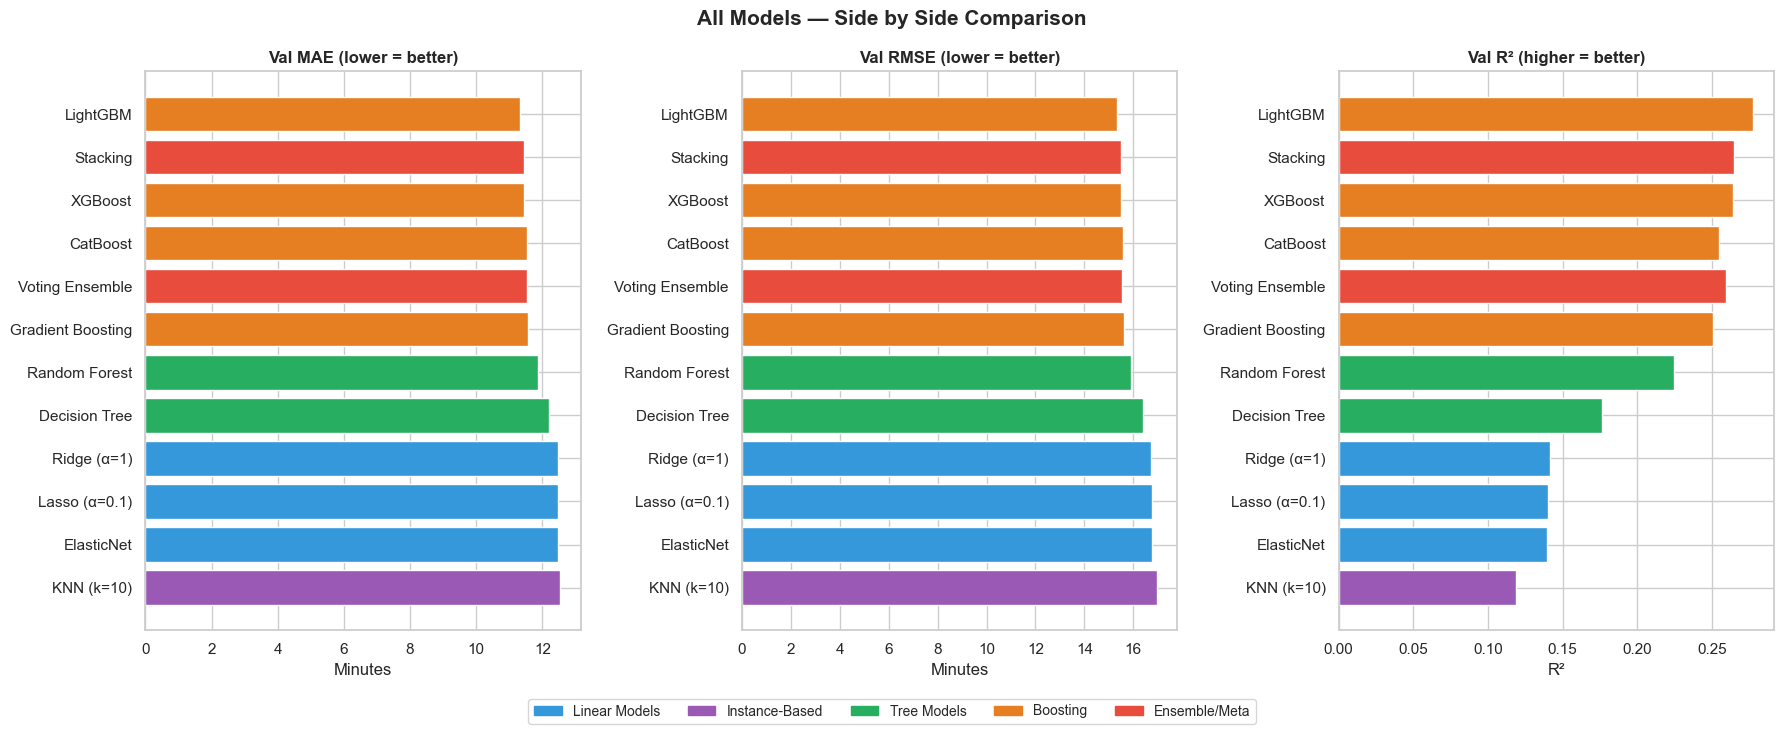

✅ Saved!


In [19]:
# ── CELL 18: Visual Leaderboard ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Color code by model family
family_colors = {
    'Ridge': '#3498DB', 'Lasso': '#3498DB', 'ElasticNet': '#3498DB',
    'KNN': '#9B59B6',
    'Decision Tree': '#27AE60', 'Random Forest': '#27AE60',
    'Gradient Boosting': '#E67E22', 'XGBoost': '#E67E22',
    'LightGBM': '#E67E22', 'CatBoost': '#E67E22',
    'Voting Ensemble': '#E74C3C', 'Stacking': '#E74C3C'
}
bar_colors = [next((v for k, v in family_colors.items() if k in idx), '#888888')
              for idx in results_df.index]

# Val MAE
axes[0].barh(results_df.index, results_df['Val MAE'],
             color=bar_colors, edgecolor='white')
axes[0].set_title('Val MAE (lower = better)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Minutes')
axes[0].invert_yaxis()

# Val RMSE
axes[1].barh(results_df.index, results_df['Val RMSE'],
             color=bar_colors, edgecolor='white')
axes[1].set_title('Val RMSE (lower = better)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Minutes')
axes[1].invert_yaxis()

# Val R²
axes[2].barh(results_df.index, results_df['Val R²'],
             color=bar_colors, edgecolor='white')
axes[2].set_title('Val R² (higher = better)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('R²')
axes[2].invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color='#3498DB', label='Linear Models'),
    Patch(color='#9B59B6', label='Instance-Based'),
    Patch(color='#27AE60', label='Tree Models'),
    Patch(color='#E67E22', label='Boosting'),
    Patch(color='#E74C3C', label='Ensemble/Meta'),
]
fig.legend(handles=legend, loc='lower center', ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, -0.05))

plt.suptitle('All Models — Side by Side Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/04_full_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved!')

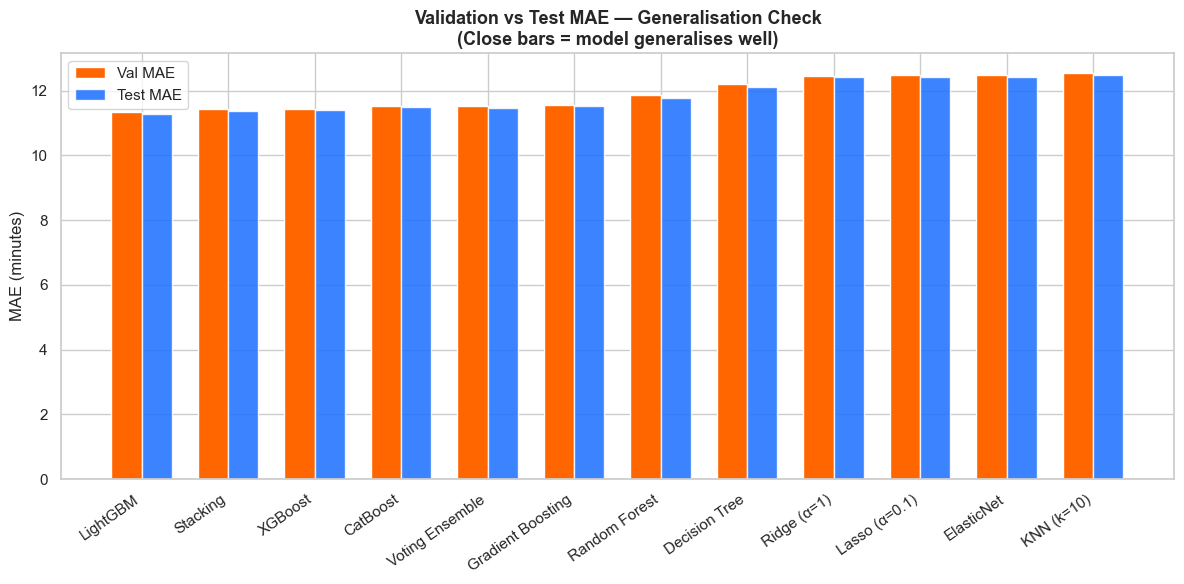

💡 If Test MAE >> Val MAE → model overfit to validation data


In [20]:
# ── CELL 19: Val MAE vs Test MAE — Generalisation Check ──────────────
# A model that does well on val but poorly on test = overfit
# We want val and test scores to be CLOSE to each other

plt.figure(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.35

plt.bar(x - width/2, results_df['Val MAE'], width, label='Val MAE',
        color='#FF6600', edgecolor='white')
plt.bar(x + width/2, results_df['Test MAE'], width, label='Test MAE',
        color='#1a6eff', edgecolor='white', alpha=0.85)

plt.xticks(x, results_df.index, rotation=35, ha='right')
plt.title('Validation vs Test MAE — Generalisation Check\n(Close bars = model generalises well)',
          fontsize=13, fontweight='bold')
plt.ylabel('MAE (minutes)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/04_val_vs_test_mae.png', dpi=150)
plt.show()
print('💡 If Test MAE >> Val MAE → model overfit to validation data')

In [21]:
# ── CELL 20: Save Best Model ──────────────────────────────────────────
best_name  = results_df['Val MAE'].idxmin()

# Map name back to trained model object
model_map = {
    'Ridge (α=1)': ridge, 'Lasso (α=0.1)': lasso, 'ElasticNet': enet,
    'KNN (k=10)': knn, 'Decision Tree': dt, 'Random Forest': rf,
    'Gradient Boosting': gbm, 'XGBoost': xgb, 'LightGBM': lgbm,
    'CatBoost': cat, 'Voting Ensemble': voting_model, 'Stacking': stacking_model
}
best_model = model_map[best_name]

with open('../outputs/models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save predictions
X_test_input = X_test_s if best_name in ['Ridge (α=1)', 'Lasso (α=0.1)',
                                           'ElasticNet', 'KNN (k=10)', 'Stacking'] else X_test
y_pred_test = best_model.predict(X_test_input)
pd.DataFrame({'actual': y_test.values, 'predicted': y_pred_test}).to_csv(
    '../outputs/models/test_predictions.csv', index=False
)

# Save full leaderboard
results_df.to_csv('../outputs/models/model_leaderboard.csv')

print(f'✅ Best model: {best_name}')
print(f'✅ Saved to outputs/models/best_model.pkl')
print(f'✅ Leaderboard saved to outputs/models/model_leaderboard.csv')

✅ Best model: LightGBM
✅ Saved to outputs/models/best_model.pkl
✅ Leaderboard saved to outputs/models/model_leaderboard.csv


---
## 📝 Modeling Notes & Observations
*(Fill this in after running — copy to docs/decisions.md)*

### What to observe in each family:

**Linear Models:** Did regularization help vs plain Linear Regression? Which alpha worked best?

**KNN:** What K gave the best result? Where did it start overfitting (K too low) or underfitting (K too high)?

**Decision Tree:** At what depth did overfitting start? How big was the train vs val MAE gap?

**Random Forest vs GBM:** Which was better? What does this tell you about this dataset?

**XGBoost vs LightGBM vs CatBoost:** Which boosting library won? Were results close?

**Ensemble:** Did Voting / Stacking beat the best individual model?

### My Results:
- **Best model:** 
- **Worst model:** 
- **Biggest surprise:** 
- **Linear vs Tree vs Boosting — biggest winner:** 
- **Did ensembling help?** 
- **Next: tune hyperparameters of best model with GridSearchCV**